Import Libraies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

Load dataset

In [2]:
data = load_diabetes()
X = data.data
y = data.target

View dataset

In [3]:
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y
print(df.head())


        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


Split dataset

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Feature scaling

In [5]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

 Create models

In [6]:
ridge_model = Ridge(alpha=1.0)
lasso_model = Lasso(alpha=0.1)
elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5)

Train models

In [7]:
ridge_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)
elastic_model.fit(X_train, y_train)

ElasticNet(alpha=0.1)

Predictions

In [8]:
ridge_pred = ridge_model.predict(X_test)
lasso_pred = lasso_model.predict(X_test)
elastic_pred = elastic_model.predict(X_test)

Evaluation

In [9]:
results = pd.DataFrame({
    'Model': ['Ridge', 'Lasso', 'Elastic Net'],
    'MSE': [
        mean_squared_error(y_test, ridge_pred),
        mean_squared_error(y_test, lasso_pred),
        mean_squared_error(y_test, elastic_pred)
    ],
    'R2 Score': [
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred),
        r2_score(y_test, elastic_pred)
    ]
})

print("\nModel Performance:\n")
print(results)


Model Performance:

         Model          MSE  R2 Score
0        Ridge  2892.014566  0.454147
1        Lasso  2884.624289  0.455541
2  Elastic Net  2866.461255  0.458970


 Compare coefficients

In [10]:
coef_df = pd.DataFrame({
    'Feature': data.feature_names,
    'Ridge': ridge_model.coef_,
    'Lasso': lasso_model.coef_,
    'ElasticNet': elastic_model.coef_
})

print("\nModel Coefficients:\n")
print(coef_df)


Model Coefficients:

  Feature      Ridge      Lasso  ElasticNet
0     age   1.807342   1.730451    1.901571
1     sex -11.448190 -11.316359  -10.622680
2     bmi  25.732699  25.824627   25.235960
3      bp  16.734300  16.644252   15.999903
4      s1 -34.671954 -29.358412   -8.892999
5      s2  17.053075  13.275844   -2.078835
6      s3   3.369914   0.547948   -7.816070
7      s4  11.764260  10.236168    7.707688
8      s5  31.378384  29.632826   20.998064
9      s6   2.458139   2.393475    3.151914


Plot coefficient comparison

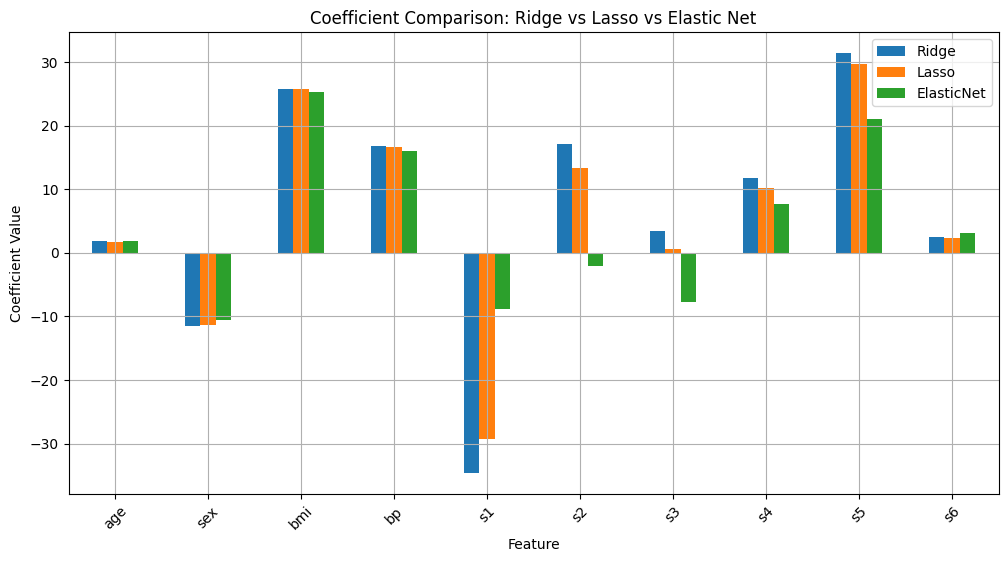

In [11]:
coef_df.set_index('Feature').plot(kind='bar', figsize=(12,6))
plt.title("Coefficient Comparison: Ridge vs Lasso vs Elastic Net")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()